In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-18 12:12:25.404211


In [47]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import math
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [48]:
plt.rcParams['figure.figsize'] = (3,3)
plt.rcParams["figure.dpi"] = 150

In [49]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_04/04b_reclustered"
output_dir = BASE_DIR / "figures"

output_dir.mkdir(parents=True, exist_ok=True)

input_file = input_dir / "neurons-seurat.h5ad"

In [50]:
sc.settings.figdir = output_dir

In [51]:
adata = sc.read_h5ad(input_file)
adata

AnnData object with n_obs × n_vars = 22411 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predicti

## Prepare data

In [52]:
adata.X = adata.layers['log1p'].copy()

In [53]:
# subset to CGRP-Gamma
adata = adata[adata.obs['seurat_labels'] == 'CGRP-Gamma'].copy()

## Visualize

In [54]:
def kde_grid_plot(
    adata,
    genes,
    group_col="EGFP_dTomato_dual_hi",
    ncols=5,

    # --- sizing ---
    subplot_size=(3.0, 2.5),   # inches per subplot (W, H)

    # --- style ---
    palette={False: "black", True: "blue"},
    alpha={False: 0.25, True: 0.5},
    linewidth={False: 3, True: 2},
    gene_fontsize=14,
):

    sns.set_theme(style="ticks")

    # --- robust boolean conversion ---
    raw_group = adata.obs[group_col]

    if isinstance(raw_group.dtype, pd.CategoricalDtype):
        group_bool = raw_group.astype(str) == "True"
    elif raw_group.dtype == bool:
        group_bool = raw_group.values
    else:
        group_bool = (
            raw_group.astype(str)
            .str.lower()
            .isin(["true", "1", "yes"])
            .values
        )

    # --- data ---
    df = adata.to_df()[genes]

    n = len(genes)
    nrows = math.ceil(n / ncols)

    # --- FIXED subplot sizing ---
    fig_width = ncols * subplot_size[0]
    fig_height = nrows * subplot_size[1]

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(fig_width, fig_height),
        sharex=False,
        sharey=False
    )

    axes = np.atleast_1d(axes).flatten()

    for i, gene in enumerate(genes):
        ax = axes[i]
        x = df[gene].values

        for state in [False, True]:
            sns.kdeplot(
                x[group_bool == state],
                ax=ax,
                fill=True,
                color=palette[state],
                alpha=alpha[state],
                linewidth=linewidth[state],
                label=str(state)
            )

        ax.set_title(
            f"$\\it{{{gene}}}$",
            fontsize=gene_fontsize
        )

        ax.set_yticks([])
        ax.set_ylabel("")
        ax.tick_params(axis="x", labelsize=8)

    # --- hide unused axes ---
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    sns.despine()
    plt.tight_layout()

    return fig

In [55]:
genes = ['Trpv1', 'Piezo2', 'Ntrk2', 'Ntrk3', 'Adra2a']

+ Trpv1*
+ Piezo2*
+ TrkA
+ TrkB

+ Trpa1?

Mast cell mediators
(Zhen will send list, + heatmap)


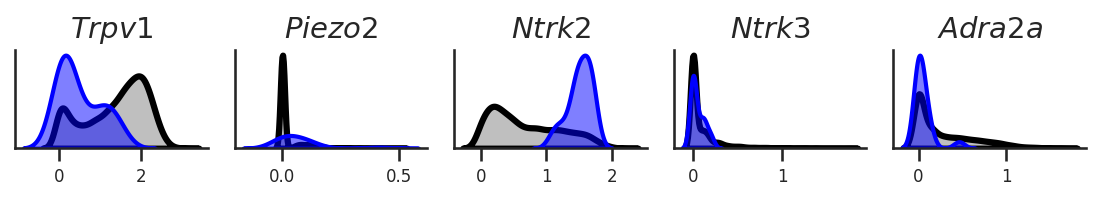

In [56]:
fig = kde_grid_plot(
    adata,
    genes=genes,
    ncols=5,
    subplot_size=(1.5, 1.5),
    palette={False: "black", True: "blue"},
    group_col="EGFP_dTomato_dual_hi"
)

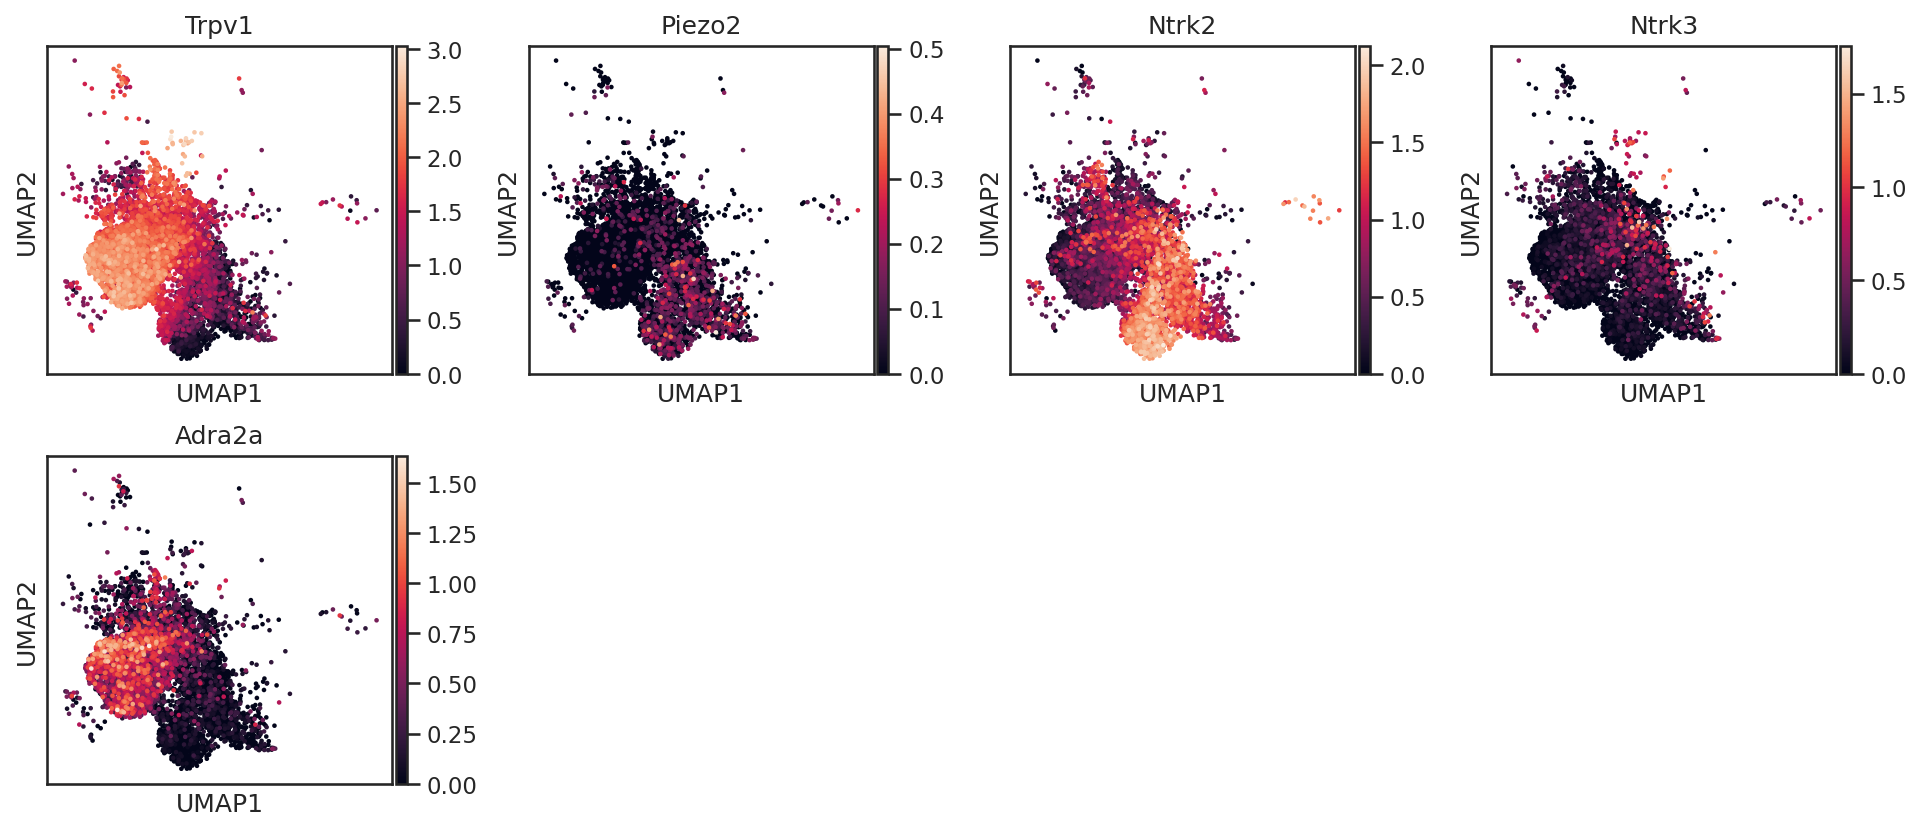

In [58]:
sc.pl.umap(adata, color = genes) 
# Looks like they have higher expression of Piezo2 but the histogram is noisy. Can we show Piezo2 expression at the cluster level since expression is so low?

In [ ]:
sc.pl.matrixplot(adata, var_names = ['', '', ''], groupby = 'seurat_labels')